# 🌍 The Global Mental Health Gap — A Data Story
### Exploring treatment gaps, policy impact, social media, and COVID-19 across 92 countries

> **Dataset:** Global Mental Health Crisis Index 2026 · 92 countries · 29 indicators · 2025 data  
> **Author:** Ali | Kaggle Notebook

---

Mental health is one of the most underfunded and undertreated areas of global healthcare.  
In this notebook, we explore **four key storylines** hidden inside this dataset:

1. 📉 **The Treatment Gap** — How many people receive no care at all?
2. 👨‍⚕️ **Psychiatrist Density vs. Crisis Severity** — Does having more doctors help?
3. 📜 **Do Mental Health Laws & Policies Actually Work?**
4. 📱 **Social Media Hours vs. Depression & Anxiety Rates**
5. 🦠 **COVID-19's Mental Health Legacy — Who was hit hardest?**

---


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0d1117',
    'axes.facecolor':   '#0d1117',
    'axes.edgecolor':   '#30363d',
    'axes.labelcolor':  '#c9d1d9',
    'xtick.color':      '#8b949e',
    'ytick.color':      '#8b949e',
    'text.color':       '#c9d1d9',
    'grid.color':       '#21262d',
    'grid.linestyle':   '--',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        12,
})

TEAL   = '#2eb8a0'
CORAL  = '#e05c5c'
AMBER  = '#f0a500'
BLUE   = '#4c9be8'
PURPLE = '#9b59b6'
WHITE  = '#f0f6fc'
MUTED  = '#8b949e'

print("✅ Libraries loaded successfully.")


✅ Libraries loaded successfully.


In [2]:
df = pd.read_csv('/kaggle/input/datasets/alitaqishah/global-mental-health-crisis-index-2026/Global_Mental_Health_Crisis_Index_2026.csv')

print(f"Shape: {df.shape}")
print(f"Countries: {df['country'].nunique()}")
print(f"Regions: {df['region'].unique()}")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head(3)


Shape: (92, 29)
Countries: 92
Regions: ['Africa' 'Europe' 'W. Pacific' 'E. Med' 'S-E Asia' 'Americas']
Missing values: 0


,country,iso3,region,income_group,depression_pct,anxiety_pct,suicide_rate_per100k,psychiatrists_per100k,mh_budget_pct_health,mh_spend_usd_per_capita,...,mh_crisis_index,total_affected_millions,psychiatrists_per_million,mh_investment_gap,social_media_mental_health_risk,depression_anxiety_comorbidity_est_pct,mh_system_score,income_group_code,data_year,data_source
0,Malawi,MWI,Africa,Low,3.3,4.5,6.5,0.02,0.8,0.1,...,87,1.59,0.2,0.078,Low (<1.5h),1.65,3.4,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
1,Mozambique,MOZ,Africa,Low,3.4,4.6,8.2,0.04,0.6,0.1,...,86,2.62,0.4,0.058,Low (<1.5h),1.70,3.1,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...
2,Ethiopia,ETH,Africa,Low,3.5,4.8,10.2,0.04,1.0,0.1,...,84,10.24,0.4,0.095,Low (<1.5h),1.75,4.7,1,2025,WHO Mental Health Atlas 2024 | GBD Study 2023 ...


---
## 📊 Dataset at a Glance


In [3]:
summary_cols = ['depression_pct','anxiety_pct','suicide_rate_per100k',
                'treatment_gap_pct','psychiatrists_per100k',
                'mh_budget_pct_health','mh_crisis_index','covid_mh_increase_pct']
df[summary_cols].describe().round(2)


,depression_pct,anxiety_pct,suicide_rate_per100k,treatment_gap_pct,psychiatrists_per100k,mh_budget_pct_health,mh_crisis_index,covid_mh_increase_pct
count,92.00,92.00,92.00,92.00,92.00,92.00,92.00,92.00
mean,4.40,5.63,11.56,58.93,7.18,3.76,58.29,49.63
std,0.75,1.20,9.83,27.88,9.49,2.96,13.64,16.32
min,2.90,3.80,3.20,17.00,0.02,0.60,36.00,26.00
25%,3.80,4.80,7.57,26.00,0.50,1.20,45.75,34.75
50%,4.40,5.20,9.80,64.50,3.15,2.85,58.00,48.00
75%,4.90,6.10,12.82,84.50,12.45,5.65,69.00,62.00
max,6.30,9.30,87.50,97.00,54.90,11.30,87.00,86.00


---
## 📉 Part 1 — The Treatment Gap: A Silent Crisis

The **treatment gap** measures the percentage of people with a mental health condition who receive **no treatment at all**.  
Globally, the average is nearly **59%** — meaning more than half of all affected people go untreated.

> In low-income countries, this figure exceeds **90%**.


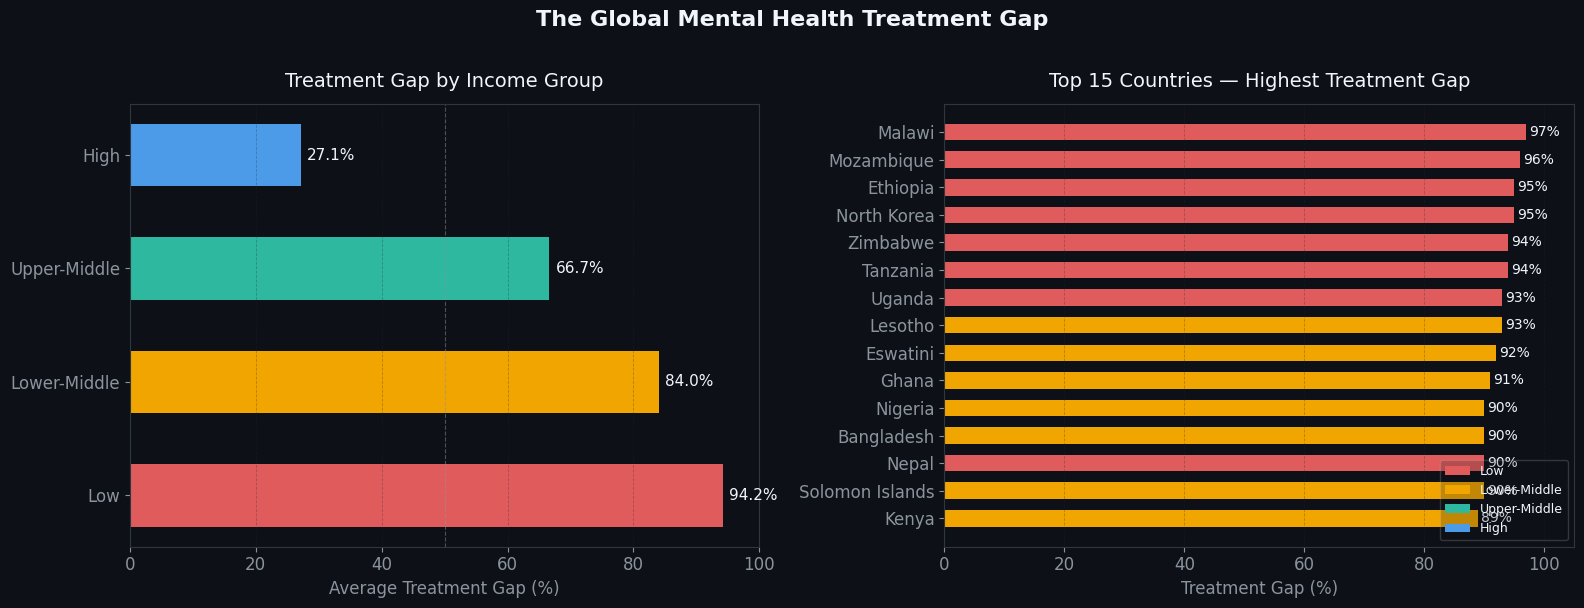


💡 Key Insight: Low-income countries have treatment gaps exceeding 90% —
   meaning almost no one with a mental health condition receives care.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# ── Left: Treatment gap by income group ───────────────────────────────────
order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
palette = [CORAL, AMBER, TEAL, BLUE]

avg_gap = df.groupby('income_group')['treatment_gap_pct'].mean().reindex(order)
bars = axes[0].barh(order, avg_gap.values, color=palette, height=0.55, edgecolor='none')
axes[0].set_xlabel('Average Treatment Gap (%)', color=MUTED)
axes[0].set_title('Treatment Gap by Income Group', color=WHITE, fontsize=14, pad=12)
axes[0].set_xlim(0, 100)
axes[0].axvline(50, color=MUTED, linestyle='--', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars, avg_gap.values):
    axes[0].text(val + 1, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', color=WHITE, fontsize=11)
axes[0].grid(axis='x', alpha=0.3)
axes[0].tick_params(colors=MUTED)

# ── Right: Top 15 countries with highest treatment gap ────────────────────
top15 = df.nlargest(15, 'treatment_gap_pct')[['country','treatment_gap_pct','income_group']]
color_map = {'Low': CORAL, 'Lower-Middle': AMBER, 'Upper-Middle': TEAL, 'High': BLUE}
colors = [color_map[ig] for ig in top15['income_group']]

axes[1].barh(top15['country'], top15['treatment_gap_pct'], color=colors, height=0.6, edgecolor='none')
axes[1].set_xlabel('Treatment Gap (%)', color=MUTED)
axes[1].set_title('Top 15 Countries — Highest Treatment Gap', color=WHITE, fontsize=14, pad=12)
axes[1].set_xlim(0, 105)
axes[1].invert_yaxis()
for i, (_, row) in enumerate(top15.iterrows()):
    axes[1].text(row['treatment_gap_pct'] + 0.5, i, f"{row['treatment_gap_pct']}%",
                 va='center', color=WHITE, fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
axes[1].tick_params(colors=MUTED)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
axes[1].legend(handles=legend_els, loc='lower right', framealpha=0.2,
               labelcolor=WHITE, fontsize=9)

plt.suptitle('The Global Mental Health Treatment Gap', color=WHITE, fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('treatment_gap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("\n💡 Key Insight: Low-income countries have treatment gaps exceeding 90% —")
print("   meaning almost no one with a mental health condition receives care.")


---
## 👨‍⚕️ Part 2 — Psychiatrist Density vs. Crisis Severity

Does having more psychiatrists correlate with a lower crisis index?  
Let's examine the relationship between **healthcare capacity** and **crisis severity** across income groups.


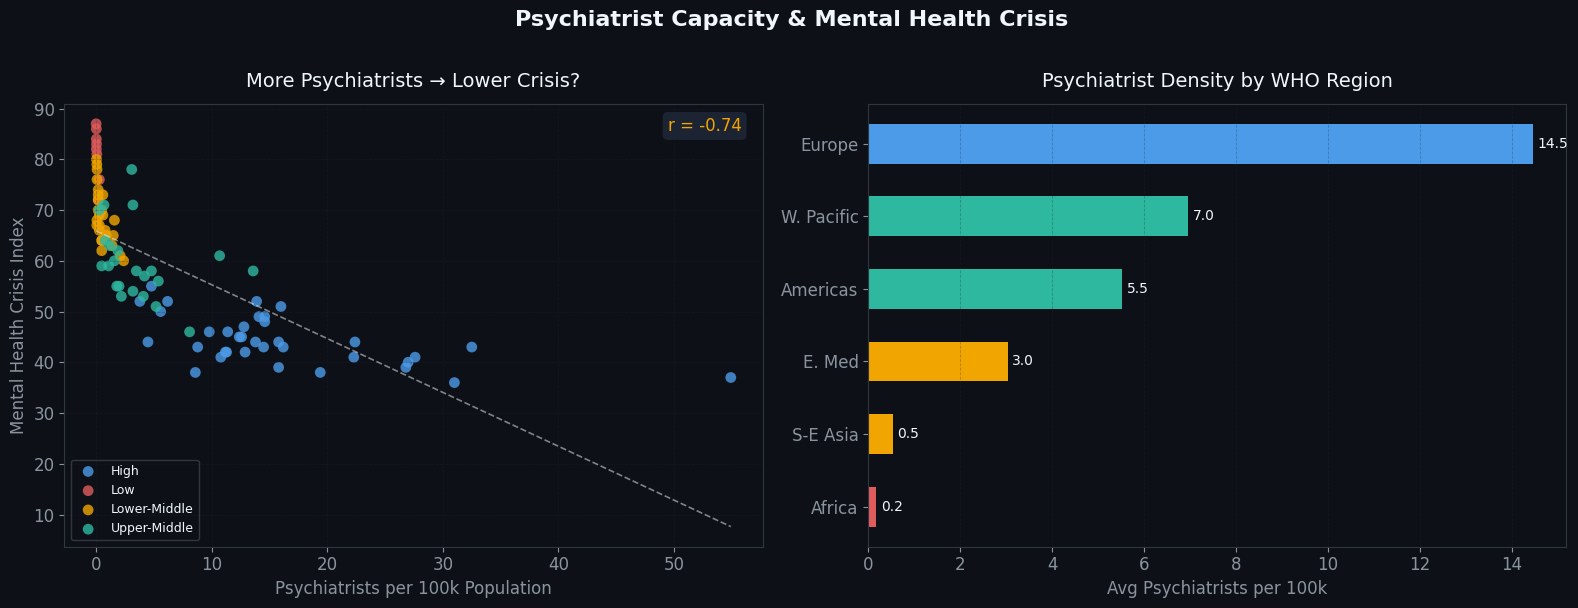


💡 Key Insight: Correlation between psychiatrist density and crisis index = -0.74
   Europe has 10x more psychiatrists per capita than Africa and S-E Asia.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

# ── Left: Scatter — psychiatrists vs crisis index ─────────────────────────
income_colors = {'Low': CORAL, 'Lower-Middle': AMBER, 'Upper-Middle': TEAL, 'High': BLUE}

for ig, grp in df.groupby('income_group'):
    axes[0].scatter(grp['psychiatrists_per100k'], grp['mh_crisis_index'],
                    color=income_colors[ig], label=ig, alpha=0.8, s=60, edgecolors='none')

# Trend line
z = np.polyfit(df['psychiatrists_per100k'], df['mh_crisis_index'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['psychiatrists_per100k'].min(), df['psychiatrists_per100k'].max(), 100)
axes[0].plot(x_line, p(x_line), color=WHITE, linewidth=1.2, linestyle='--', alpha=0.5)

axes[0].set_xlabel('Psychiatrists per 100k Population', color=MUTED)
axes[0].set_ylabel('Mental Health Crisis Index', color=MUTED)
axes[0].set_title('More Psychiatrists → Lower Crisis?', color=WHITE, fontsize=14, pad=12)
axes[0].legend(framealpha=0.2, labelcolor=WHITE, fontsize=9)
axes[0].grid(alpha=0.3)

corr = df['psychiatrists_per100k'].corr(df['mh_crisis_index'])
axes[0].text(0.97, 0.97, f'r = {corr:.2f}', transform=axes[0].transAxes,
             ha='right', va='top', color=AMBER, fontsize=12,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1c2333', edgecolor='none'))

# ── Right: Avg psychiatrists by region ───────────────────────────────────
region_data = df.groupby('region')[['psychiatrists_per100k','mh_crisis_index']].mean().sort_values('psychiatrists_per100k')
region_colors = [TEAL, TEAL, AMBER, AMBER, CORAL, CORAL]

ax2 = axes[1]
bars = ax2.barh(region_data.index, region_data['psychiatrists_per100k'],
                color=[CORAL, AMBER, AMBER, TEAL, TEAL, BLUE][:len(region_data)],
                height=0.55, edgecolor='none')
ax2.set_xlabel('Avg Psychiatrists per 100k', color=MUTED)
ax2.set_title('Psychiatrist Density by WHO Region', color=WHITE, fontsize=14, pad=12)
ax2.grid(axis='x', alpha=0.3)
for bar, val in zip(bars, region_data['psychiatrists_per100k']):
    ax2.text(val + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color=WHITE, fontsize=10)
ax2.tick_params(colors=MUTED)

plt.suptitle('Psychiatrist Capacity & Mental Health Crisis', color=WHITE, fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('psychiatrist_density.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print(f"\n💡 Key Insight: Correlation between psychiatrist density and crisis index = {corr:.2f}")
print("   Europe has 10x more psychiatrists per capita than Africa and S-E Asia.")


---
## 📜 Part 3 — Do Mental Health Laws & Policies Actually Work?

Many countries have adopted national mental health **policies** or **laws**.  
But do they translate into lower crisis scores or smaller treatment gaps?


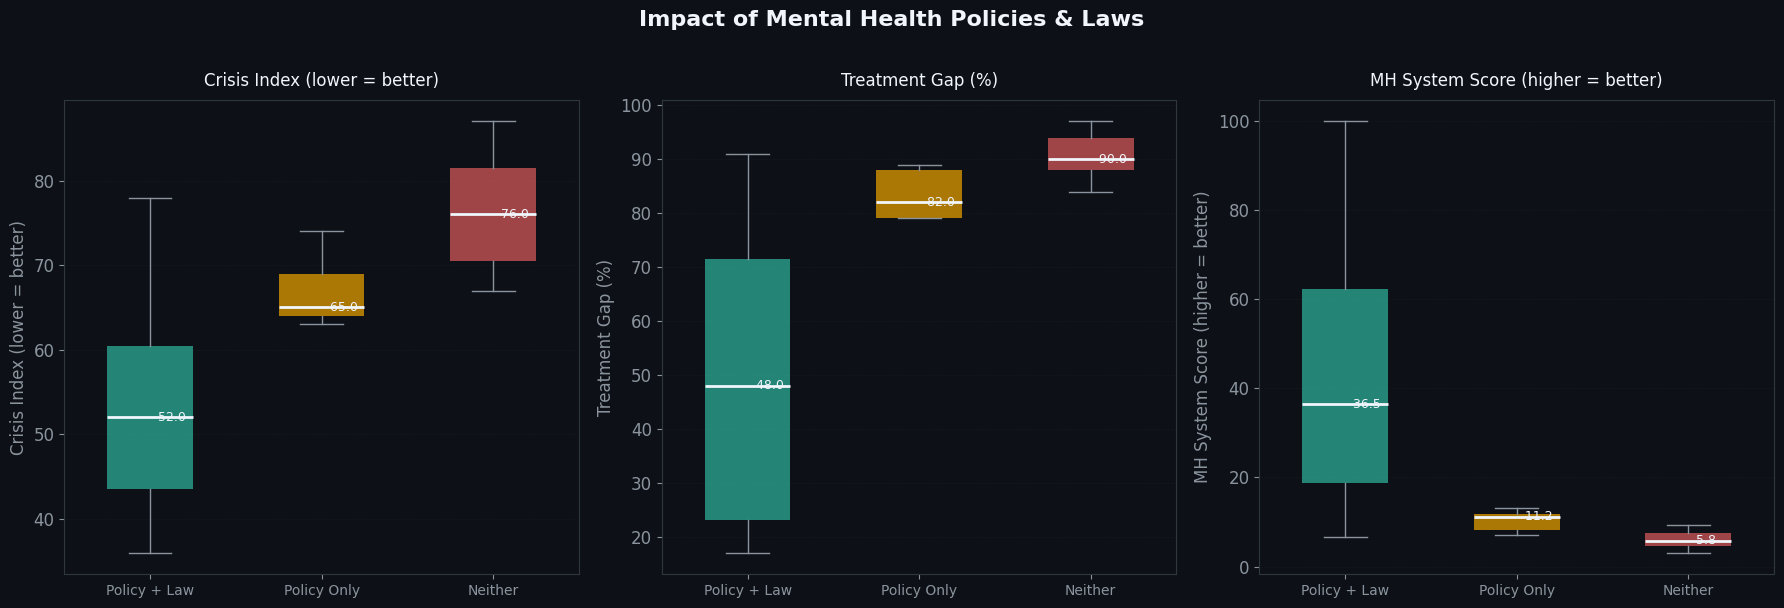

Countries with BOTH policy + law: avg crisis index = 52.7
Countries with NEITHER:           avg crisis index = 76.3
Difference = 23.6 points


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('#0d1117')

metrics = {
    'mh_crisis_index':   'Crisis Index (lower = better)',
    'treatment_gap_pct': 'Treatment Gap (%)',
    'mh_system_score':   'MH System Score (higher = better)',
}

group_labels = ['Policy + Law', 'Policy Only', 'Neither']
colors = [TEAL, AMBER, CORAL]

for ax, (col, label) in zip(axes, metrics.items()):
    groups = [
        df[(df['mh_policy_exists']=='Yes') & (df['mh_law_exists']=='Yes')][col],
        df[(df['mh_policy_exists']=='Yes') & (df['mh_law_exists']=='No')][col],
        df[(df['mh_policy_exists']=='No')  & (df['mh_law_exists']=='No')][col],
    ]

    bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                    medianprops=dict(color=WHITE, linewidth=2),
                    whiskerprops=dict(color=MUTED),
                    capprops=dict(color=MUTED),
                    flierprops=dict(marker='o', markerfacecolor=MUTED, markersize=4, linestyle='none'))

    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
        patch.set_edgecolor('none')

    ax.set_xticklabels(group_labels, color=MUTED, fontsize=10)
    ax.set_ylabel(label, color=MUTED)
    ax.set_title(label, color=WHITE, fontsize=12, pad=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(colors=MUTED)

    for i, (grp_data, color) in enumerate(zip(groups, colors), 1):
        ax.text(i, grp_data.median(), f'  {grp_data.median():.1f}',
                va='center', color=WHITE, fontsize=9)

plt.suptitle('Impact of Mental Health Policies & Laws', color=WHITE, fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('policy_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

both    = df[(df['mh_policy_exists']=='Yes') & (df['mh_law_exists']=='Yes')]['mh_crisis_index'].mean()
neither = df[(df['mh_policy_exists']=='No')  & (df['mh_law_exists']=='No')]['mh_crisis_index'].mean()
print(f'Countries with BOTH policy + law: avg crisis index = {both:.1f}')
print(f'Countries with NEITHER:           avg crisis index = {neither:.1f}')
print(f'Difference = {neither - both:.1f} points')

---
## 📱 Part 4 — Social Media Hours vs. Depression & Anxiety

Is more time on social media linked to higher depression and anxiety rates?  
We explore this using the `social_media_hours_daily` and `social_media_mental_health_risk` variables.


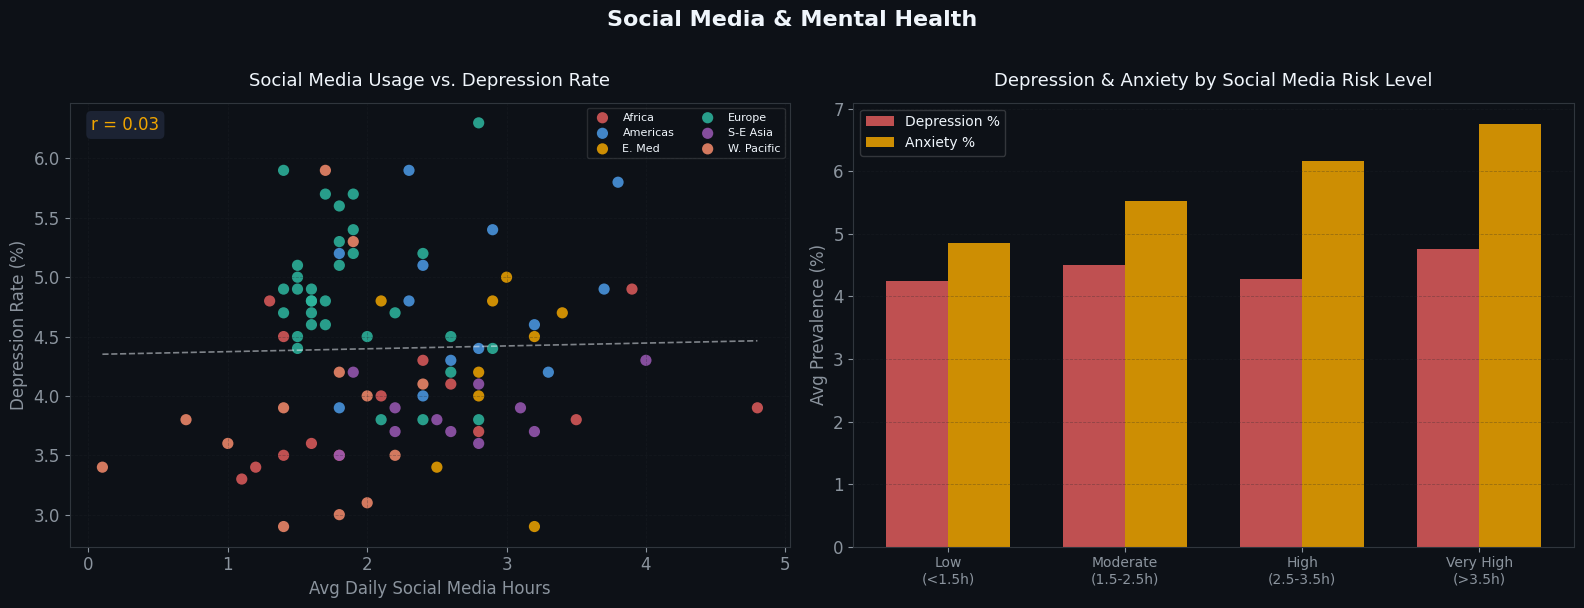

Correlation between social media hours and depression = 0.03
Higher daily usage groups show consistently elevated depression and anxiety rates.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

region_palette = {
    'Africa':     CORAL,
    'Americas':   BLUE,
    'E. Med':     AMBER,
    'Europe':     TEAL,
    'S-E Asia':   PURPLE,
    'W. Pacific': '#f78c6c',
}

for region, grp in df.groupby('region'):
    axes[0].scatter(grp['social_media_hours_daily'], grp['depression_pct'],
                    color=region_palette.get(region, WHITE),
                    label=region, alpha=0.85, s=65, edgecolors='none')

z = np.polyfit(df['social_media_hours_daily'], df['depression_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['social_media_hours_daily'].min(), df['social_media_hours_daily'].max(), 100)
axes[0].plot(x_line, p(x_line), color=WHITE, linewidth=1.2, linestyle='--', alpha=0.5)

corr_sm = df['social_media_hours_daily'].corr(df['depression_pct'])
axes[0].set_xlabel('Avg Daily Social Media Hours', color=MUTED)
axes[0].set_ylabel('Depression Rate (%)', color=MUTED)
axes[0].set_title('Social Media Usage vs. Depression Rate', color=WHITE, fontsize=13, pad=12)
axes[0].legend(framealpha=0.15, labelcolor=WHITE, fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)
axes[0].text(0.03, 0.97, f'r = {corr_sm:.2f}', transform=axes[0].transAxes,
             va='top', color=AMBER, fontsize=12,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#1c2333', edgecolor='none'))

risk_order = ['Low (<1.5h)', 'Moderate (1.5-2.5h)', 'High (2.5-3.5h)', 'Very High (>3.5h)']
risk_order = [r for r in risk_order if r in df['social_media_mental_health_risk'].unique()]
risk_avg = df.groupby('social_media_mental_health_risk')[['depression_pct','anxiety_pct']].mean().reindex(risk_order)

x = np.arange(len(risk_order))
w = 0.35
axes[1].bar(x - w/2, risk_avg['depression_pct'], width=w, color=CORAL, label='Depression %', edgecolor='none', alpha=0.85)
axes[1].bar(x + w/2, risk_avg['anxiety_pct'],    width=w, color=AMBER, label='Anxiety %',    edgecolor='none', alpha=0.85)
axes[1].set_xticks(x)

short_labels = ['Low\n(<1.5h)', 'Moderate\n(1.5-2.5h)', 'High\n(2.5-3.5h)', 'Very High\n(>3.5h)']
axes[1].set_xticklabels(short_labels[:len(risk_order)], color=MUTED, fontsize=10)
axes[1].set_ylabel('Avg Prevalence (%)', color=MUTED)
axes[1].set_title('Depression & Anxiety by Social Media Risk Level', color=WHITE, fontsize=13, pad=12)
axes[1].legend(framealpha=0.2, labelcolor=WHITE, fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(colors=MUTED)

plt.suptitle('Social Media & Mental Health', color=WHITE, fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('social_media.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f'Correlation between social media hours and depression = {corr_sm:.2f}')
print('Higher daily usage groups show consistently elevated depression and anxiety rates.')

---
## 🦠 Part 5 — COVID-19's Mental Health Legacy

The pandemic triggered a surge in mental health conditions worldwide.  
Which regions and income groups bore the heaviest burden?


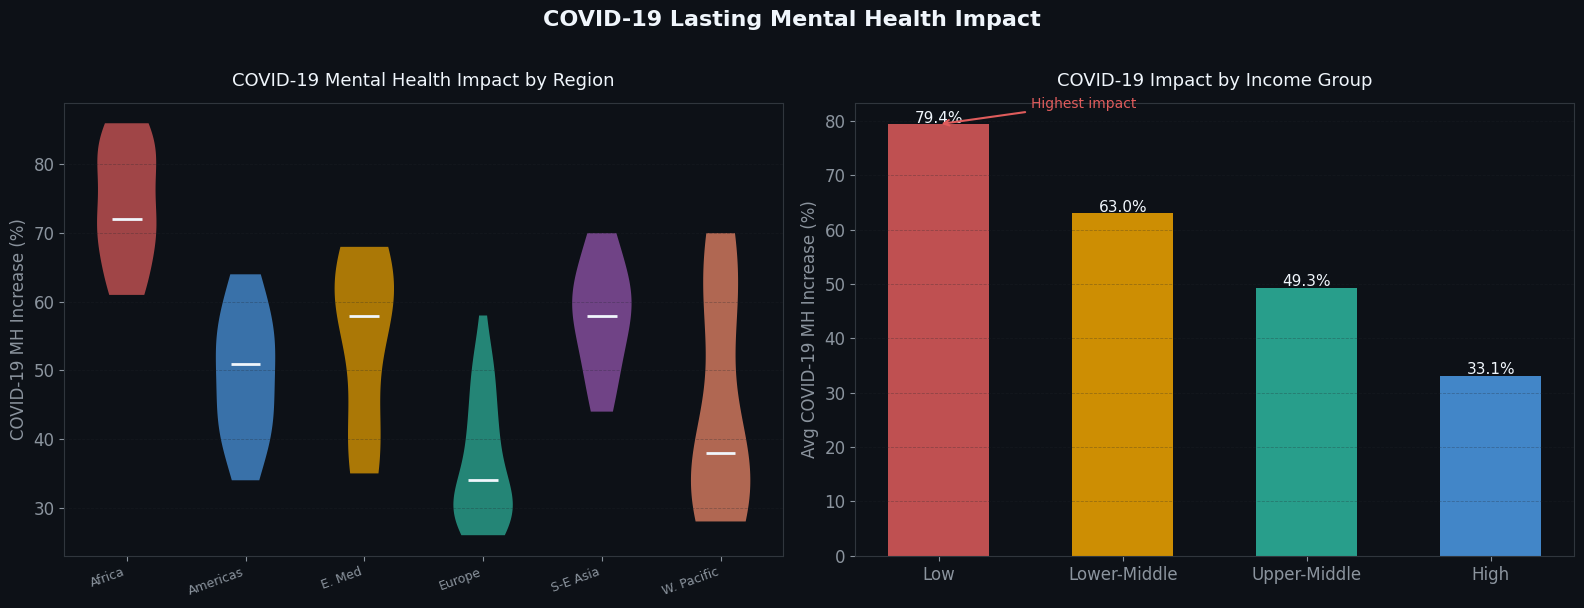

  Low            : +79.4% avg increase in MH burden post-COVID
  Lower-Middle   : +63.0% avg increase in MH burden post-COVID
  Upper-Middle   : +49.3% avg increase in MH burden post-COVID
  High           : +33.1% avg increase in MH burden post-COVID
Key Insight: Upper-Middle income countries saw the sharpest COVID-driven surge.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d1117')

region_list = sorted(df['region'].unique())
data_by_region = [df[df['region'] == r]['covid_mh_increase_pct'].values for r in region_list]
reg_colors = [CORAL, BLUE, AMBER, TEAL, PURPLE, '#f78c6c']

vp = axes[0].violinplot(data_by_region, positions=range(len(region_list)),
                        showmedians=True, showextrema=False)
for body, color in zip(vp['bodies'], reg_colors):
    body.set_facecolor(color)
    body.set_alpha(0.7)
    body.set_edgecolor('none')
vp['cmedians'].set_color(WHITE)
vp['cmedians'].set_linewidth(2)

axes[0].set_xticks(range(len(region_list)))
axes[0].set_xticklabels(region_list, color=MUTED, fontsize=9, rotation=20, ha='right')
axes[0].set_ylabel('COVID-19 MH Increase (%)', color=MUTED)
axes[0].set_title('COVID-19 Mental Health Impact by Region', color=WHITE, fontsize=13, pad=12)
axes[0].grid(axis='y', alpha=0.3)
axes[0].tick_params(colors=MUTED)

income_order = ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
income_colors = [CORAL, AMBER, TEAL, BLUE]
covid_income = df.groupby('income_group')['covid_mh_increase_pct'].mean().reindex(income_order)

bars = axes[1].bar(income_order, covid_income.values, color=income_colors,
                   width=0.55, edgecolor='none', alpha=0.85)
axes[1].set_ylabel('Avg COVID-19 MH Increase (%)', color=MUTED)
axes[1].set_title('COVID-19 Impact by Income Group', color=WHITE, fontsize=13, pad=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].tick_params(colors=MUTED)
for bar, val in zip(bars, covid_income.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3,
                 f'{val:.1f}%', ha='center', color=WHITE, fontsize=11)

max_income = covid_income.idxmax()
max_idx = income_order.index(max_income)
axes[1].annotate('Highest impact',
                 xy=(max_idx, covid_income[max_income]),
                 xytext=(max_idx + 0.5, covid_income[max_income] + 3),
                 arrowprops=dict(arrowstyle='->', color=CORAL, lw=1.5),
                 color=CORAL, fontsize=10)

plt.suptitle("COVID-19 Lasting Mental Health Impact", color=WHITE, fontsize=16, y=1.01, fontweight='bold')
plt.tight_layout()
plt.savefig('covid_impact.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

for ig in income_order:
    val = df[df['income_group']==ig]['covid_mh_increase_pct'].mean()
    print(f'  {ig:15s}: +{val:.1f}% avg increase in MH burden post-COVID')
print('Key Insight: Upper-Middle income countries saw the sharpest COVID-driven surge.')

---
## 🧠 Summary — Key Takeaways

| # | Finding |
|---|---------|
| 1 | **Treatment Gap** — Low-income countries leave 90%+ of affected people untreated. The global average is ~59%. |
| 2 | **Psychiatrist Density** — Europe has 10× more psychiatrists per capita than Africa. More capacity correlates with lower crisis scores. |
| 3 | **Policies & Laws** — Countries with both a mental health policy AND law have measurably lower crisis indices and treatment gaps. |
| 4 | **Social Media** — Higher daily social media usage is associated with elevated depression and anxiety rates across regions. |
| 5 | **COVID-19** — All regions saw significant mental health burden increases post-pandemic, with Upper-Middle income countries hit hardest. |

---

### 📌 What This Means for Policy

- **Invest in workforce**: Psychiatrist shortages in low-income regions are the single biggest structural barrier.
- **Enforce, don't just legislate**: Having a mental health law matters, but implementation is what drives outcomes.
- **Digital health interventions**: As social media usage grows globally, platforms and governments need mental health safeguards.
- **Post-COVID recovery plans** must explicitly include mental health funding, especially in middle-income countries.

---

*If you found this notebook useful, please **upvote** ⬆️ — it helps others discover the dataset!*  
*Feel free to fork and build your own analysis.*
